In [1]:
import anndata as ad
import os
import pandas as pd
import matplotlib.pyplot as plt

## Download results

In [2]:
def dict_to_pd(d):
    rows = []

    for outer_key, inner in d.items():
        row = {
            "dataset_id": inner["dataset_id"],
            "method_id": inner["method_id"],
        }
        
        # Use values from "d" as column names
        for col_name, value in zip(inner["metric_ids"], inner["metric_values"]):
            row[col_name] = value
            
        rows.append(row)
    
    df = pd.DataFrame(rows, index=d.keys())
    return df

In [3]:
methods_path = '../data/benchmark/results/metrics/methods/'

In [4]:
os.listdir(methods_path + 'nn_retraining_with_pseudolabels_mol_emb_learning_missed_subsample_fp_fixed_fp/stability')

['seed_14',
 'seed_2',
 'seed_0',
 'seed_11',
 'seed_1',
 'seed_4',
 'seed_13',
 'seed_12',
 'seed_10',
 'seed_3']

In [6]:
file_name_err = 'mean_rowwise_error.h5ad'
file_name_corr = 'mean_rowwise_correlation.h5ad'

In [7]:
methods_err = {}
methods_corr = {}
for item in os.listdir(methods_path):
    if 'mol_emb_learning' in item:
        if 'nn_retraining_with_pseudolabels_mol_emb_subsample_fp' in item:
            name = item.replace('_all_1', '')
        else:
            name = item
        name = name.replace('nn_retraining_with_pseudolabels_mol_emb_learning_missed_subsample_', '')
        stability_path = methods_path + item + '/stability'
        for seed in os.listdir(stability_path):
            
            err = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_err}').uns
            corr = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_corr}').uns
            methods_err[name + '_' + seed] = err
            methods_corr[name + '_' + seed] = corr

In [8]:
df_method_err = dict_to_pd(methods_err)

In [9]:
df_method_corr = dict_to_pd(methods_corr)

In [10]:
df_method_err['method_name'] = df_method_err.index.str.split('_seed_').str[0]
df_method_err['seed'] = df_method_err.index.str.split('_seed_').str[1].astype(int)

In [11]:
df_method_corr['method_name'] = df_method_corr.index.str.split('_seed_').str[0]
df_method_corr['seed'] = df_method_corr.index.str.split('_seed_').str[1].astype(int)

In [12]:
len(df_method_corr['method_name'].unique())

5

## Mean rowwise error

### Methods

In [13]:
df_method_err.sort_values(by="mean_rowwise_rmse")

,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae,method_name,seed
lpm_trainable_all_20_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.802382,0.566639,lpm_trainable_all_20,10
lpm_trainable_all_20_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.802922,0.567278,lpm_trainable_all_20,1
lpm_trainable_all_20_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.802923,0.567252,lpm_trainable_all_20,13
lpm_trainable_all_20_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.803084,0.566383,lpm_trainable_all_20,4
lpm_trainable_all_20_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.803332,0.567428,lpm_trainable_all_20,12
lpm_trainable_all_20_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.803536,0.567439,lpm_trainable_all_20,11
lpm_trainable_all_20_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.803557,0.568299,lpm_trainable_all_20,2
lpm_trainable_all_20_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.803908,0.569269,lpm_trainable_all_20,0
lpm_trainable_all_20_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.804126,0.568211,lpm_trainable_all_20,14
lpm_trainable_all_20_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.804146,0.568178,lpm_trainable_all_20,3


In [14]:
df_method_err

,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae,method_name,seed
fp_trainable_fp_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.811329,0.570895,fp_trainable_fp,14
fp_trainable_fp_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.811801,0.572748,fp_trainable_fp,2
fp_trainable_fp_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.811762,0.572593,fp_trainable_fp,0
fp_trainable_fp_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.811603,0.570840,fp_trainable_fp,11
fp_trainable_fp_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.811051,0.571439,fp_trainable_fp,1
fp_trainable_fp_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.811889,0.571151,fp_trainable_fp,4
fp_trainable_fp_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.811056,0.570968,fp_trainable_fp,13
fp_trainable_fp_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.812391,0.572820,fp_trainable_fp,12
fp_trainable_fp_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.811236,0.570940,fp_trainable_fp,10
fp_trainable_fp_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.811104,0.571274,fp_trainable_fp,3


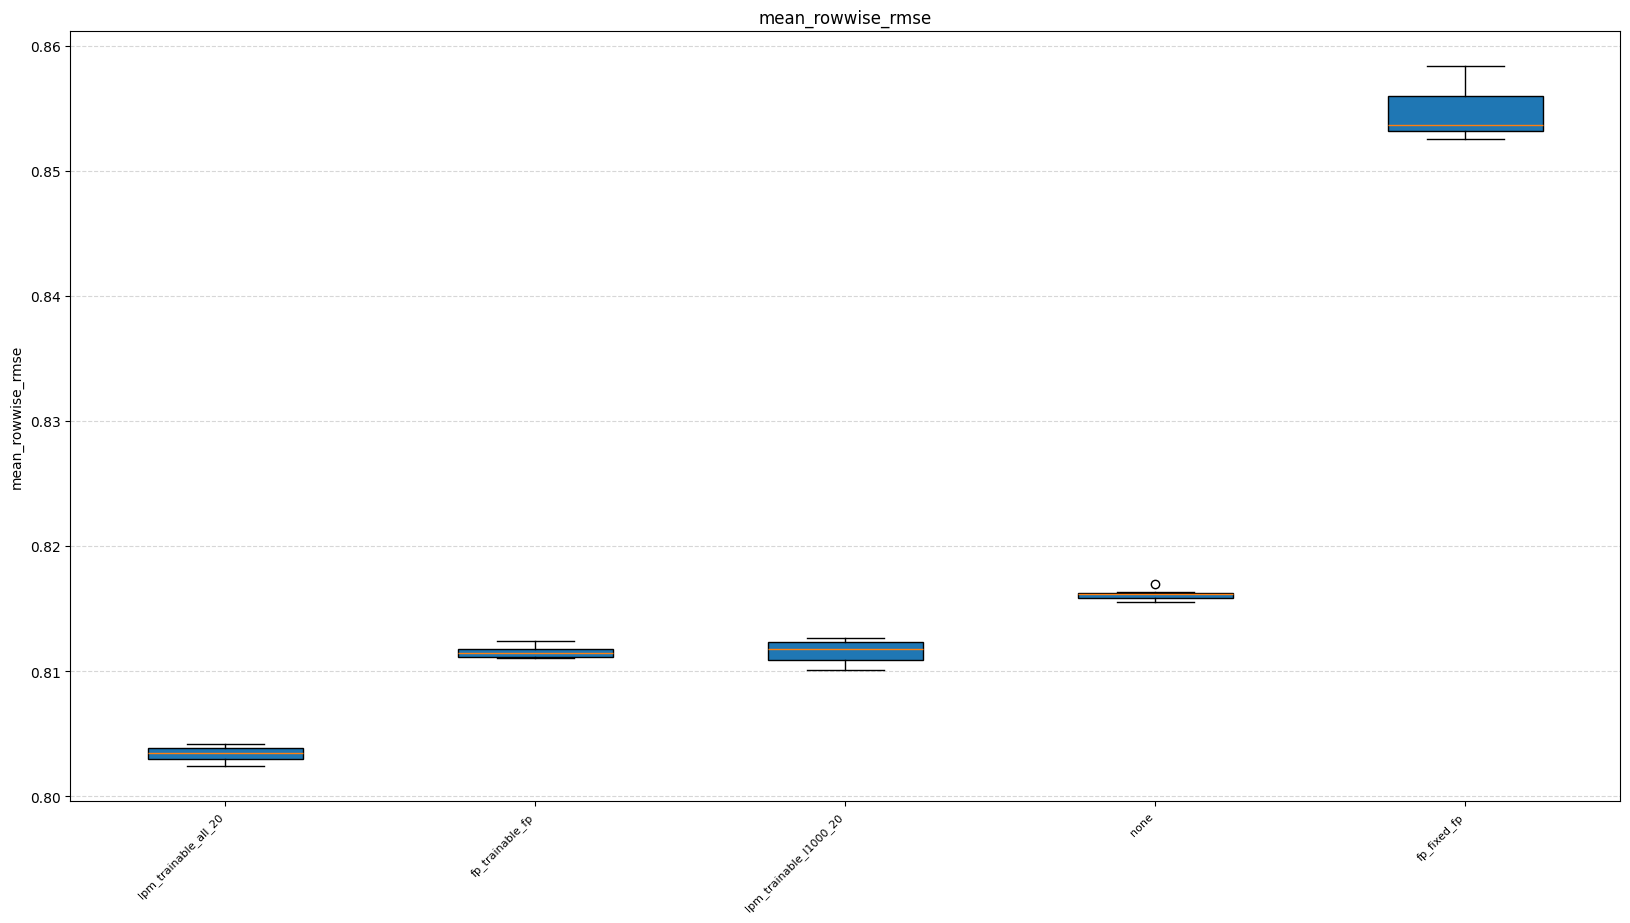

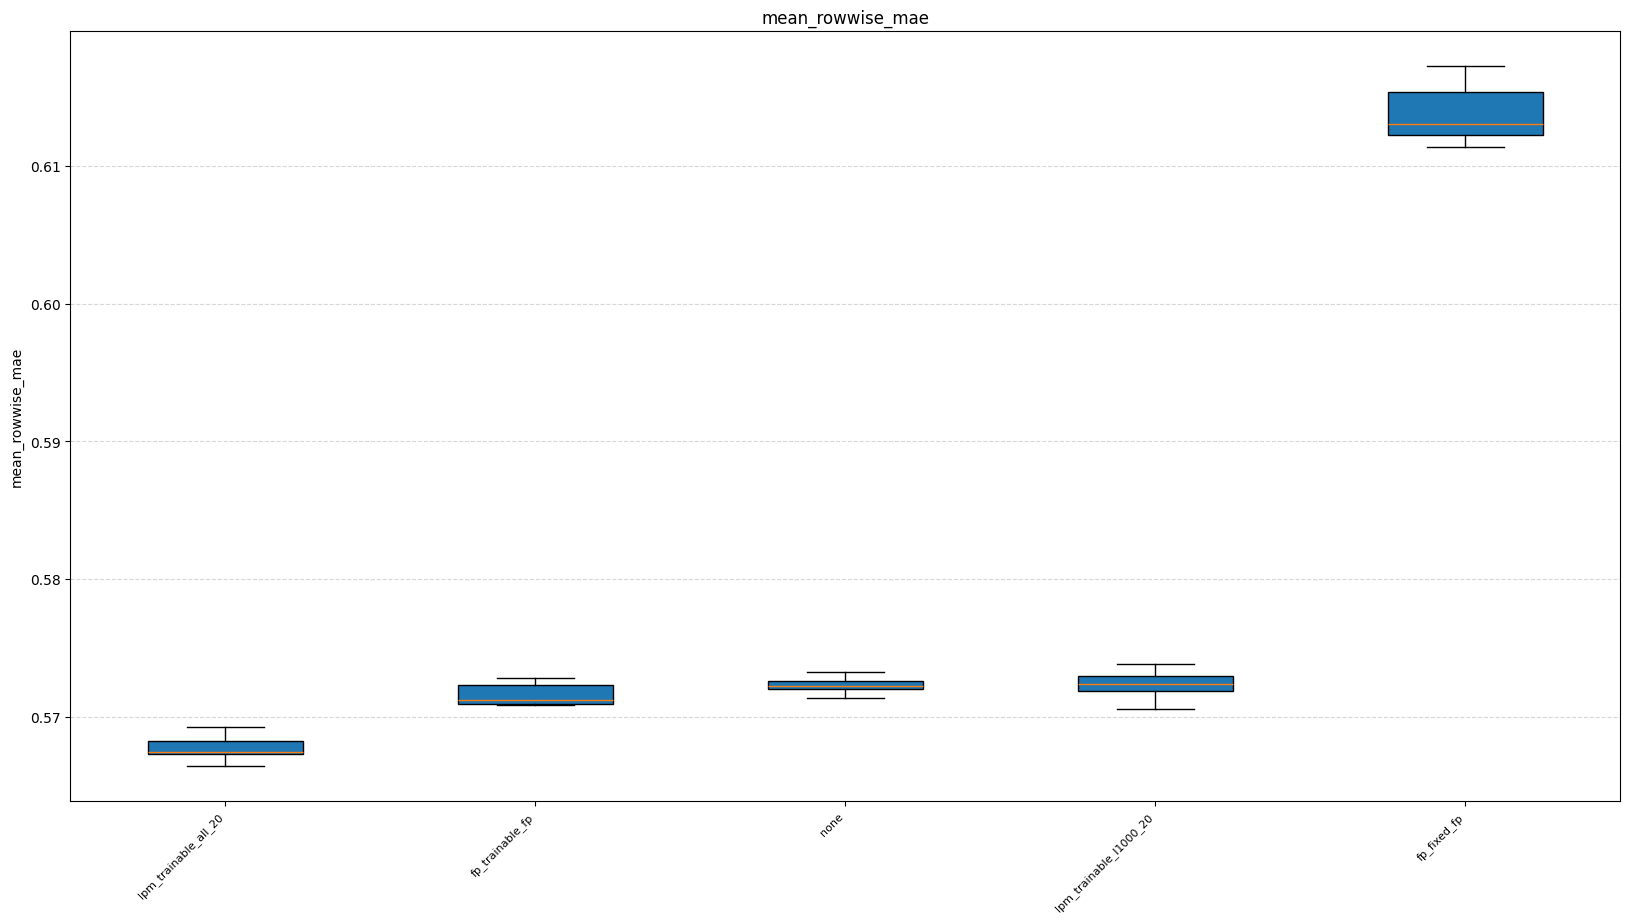

In [16]:
metrics = ["mean_rowwise_rmse", "mean_rowwise_mae"]
#fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
for metric in metrics:
    # collect values per method, ordered by median
    methods_ordered = (
        df_method_err.groupby("method_name")[metric]
        .median()
        .sort_values()
        .index.tolist()
    )
    data_per_method = [
        df_method_err.loc[df_method_err["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    plt.figure(figsize=(20, 10))
    plt.boxplot(data_per_method, patch_artist=True, vert=True)
    plt.xticks(
        range(1, len(methods_ordered) + 1),
        # strip the long common prefix for readability
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    plt.ylabel(metric)
    plt.title(metric)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()
#fig.suptitle("Stability across seeds", fontsize=13, y=1.02)
#plt.tight_layout()


## Mean rowwise correlation

### Methods

In [17]:
df_method_corr.sort_values(by="mean_rowwise_pearson", ascending=False)
#df_method_corr.sort_values(by="mean_rowwise_spearman", ascending=False)

,dataset_id,method_id,mean_rowwise_pearson,mean_rowwise_spearman,mean_rowwise_cosine,method_name,seed
lpm_trainable_all_20_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.287489,0.275914,0.291325,lpm_trainable_all_20,1
lpm_trainable_all_20_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.286850,0.275306,0.290650,lpm_trainable_all_20,12
lpm_trainable_all_20_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.286291,0.275016,0.290046,lpm_trainable_all_20,0
lpm_trainable_all_20_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.286063,0.274967,0.289933,lpm_trainable_all_20,10
lpm_trainable_all_20_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.285992,0.274639,0.289842,lpm_trainable_all_20,13
lpm_trainable_all_20_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.285976,0.274882,0.289798,lpm_trainable_all_20,2
lpm_trainable_all_20_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.285791,0.274888,0.289589,lpm_trainable_all_20,14
lpm_trainable_all_20_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.284824,0.273520,0.288745,lpm_trainable_all_20,11
lpm_trainable_all_20_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.283566,0.272759,0.287403,lpm_trainable_all_20,3
lpm_trainable_all_20_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.283515,0.272623,0.287397,lpm_trainable_all_20,4


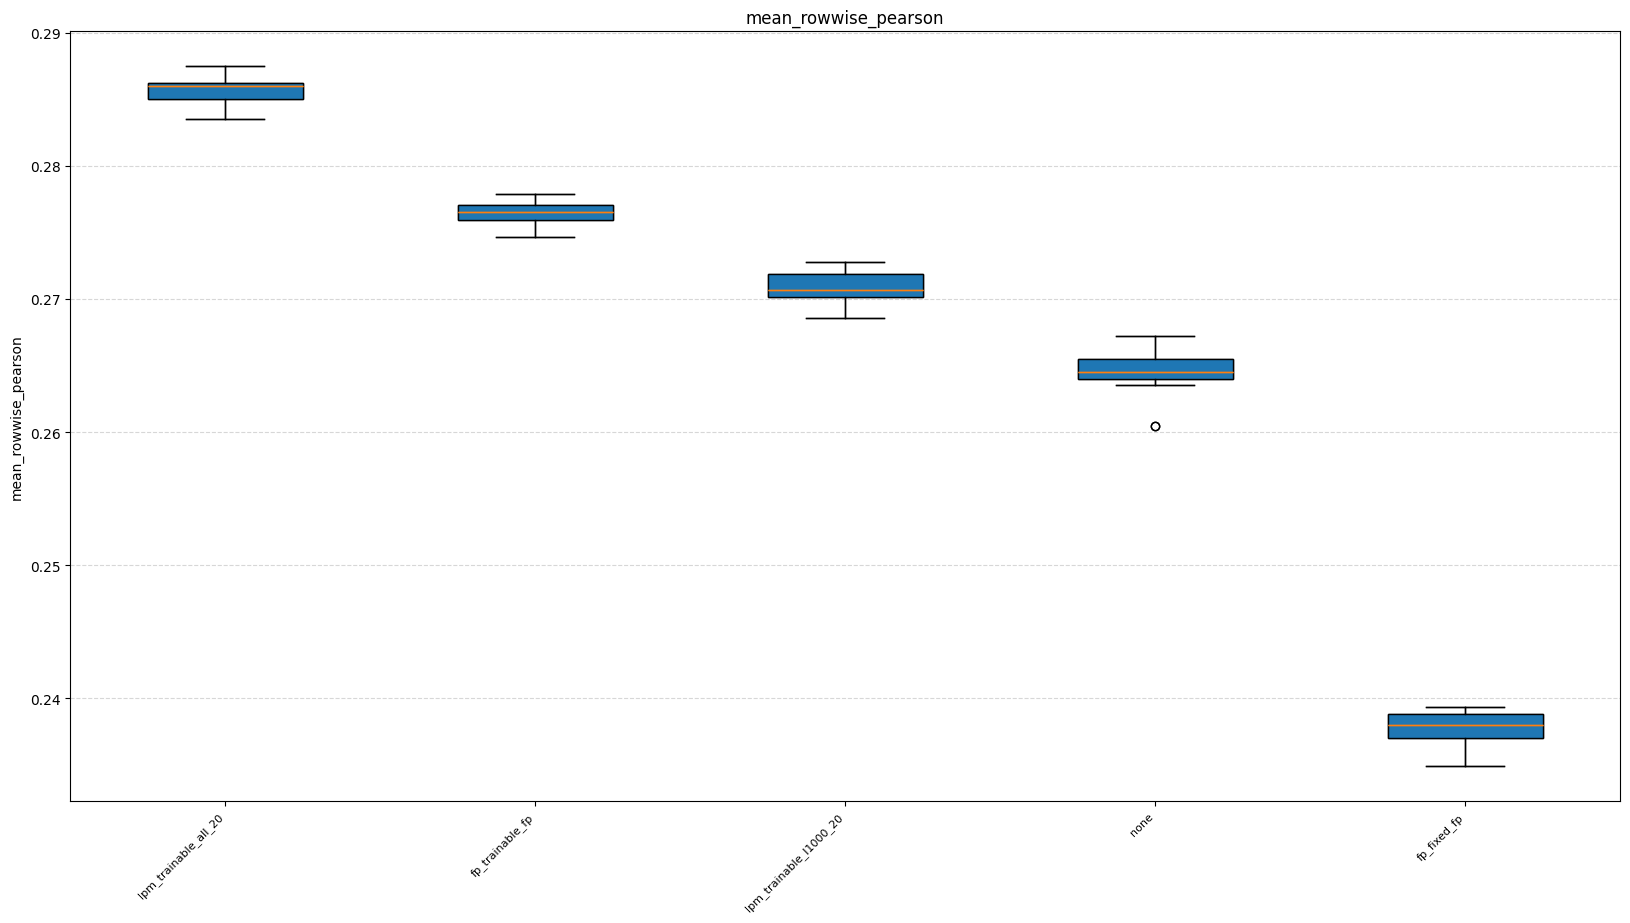

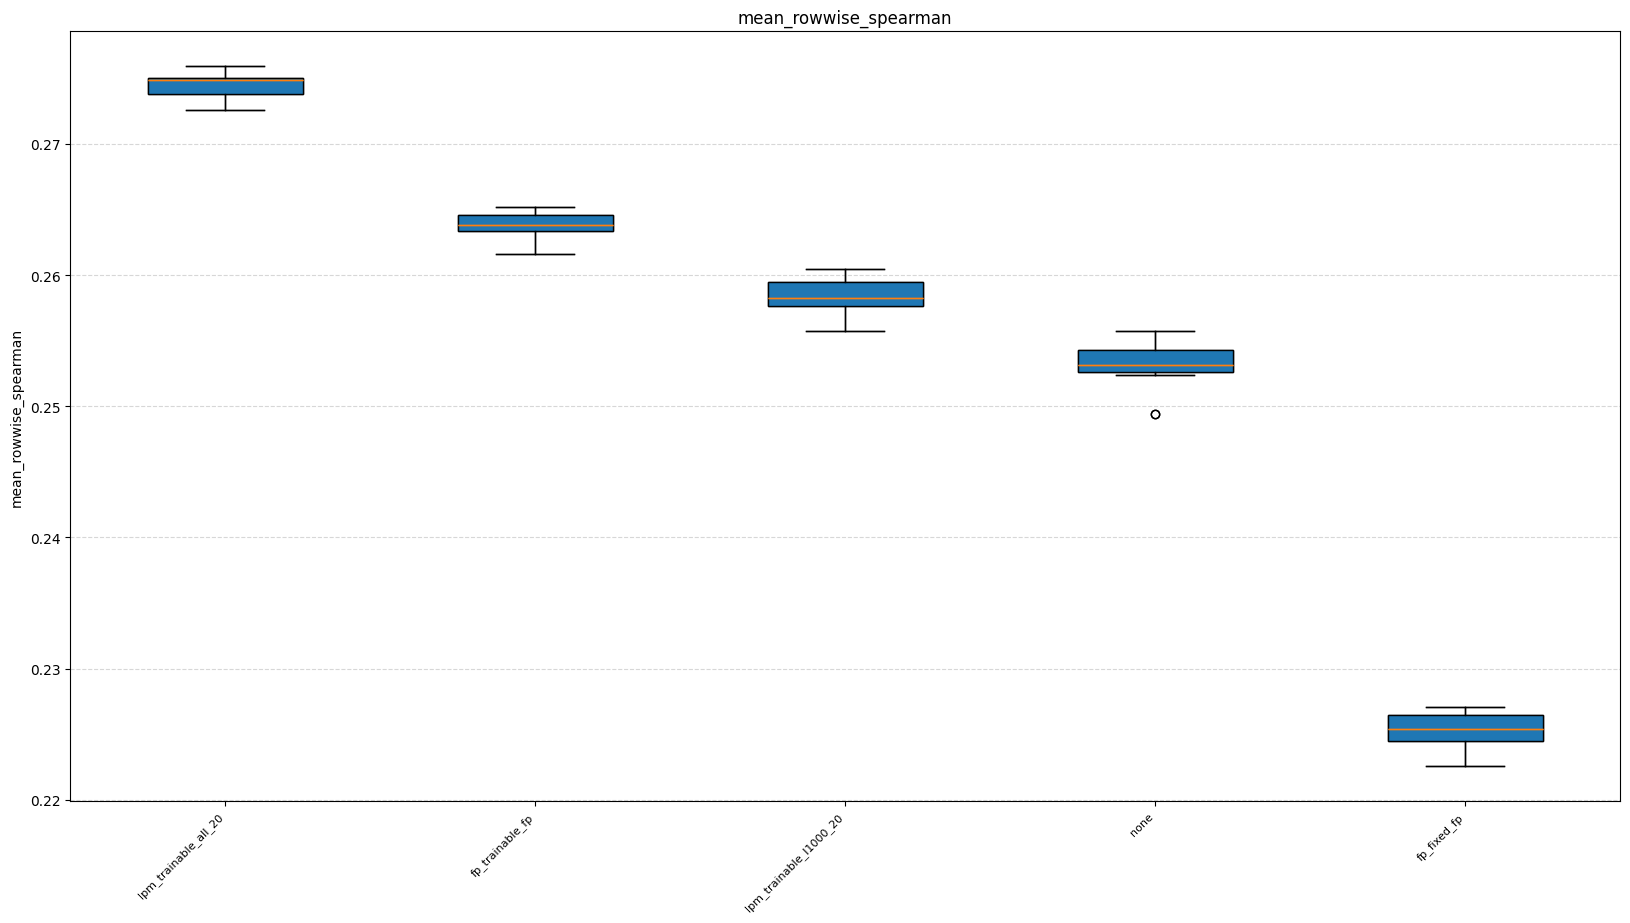

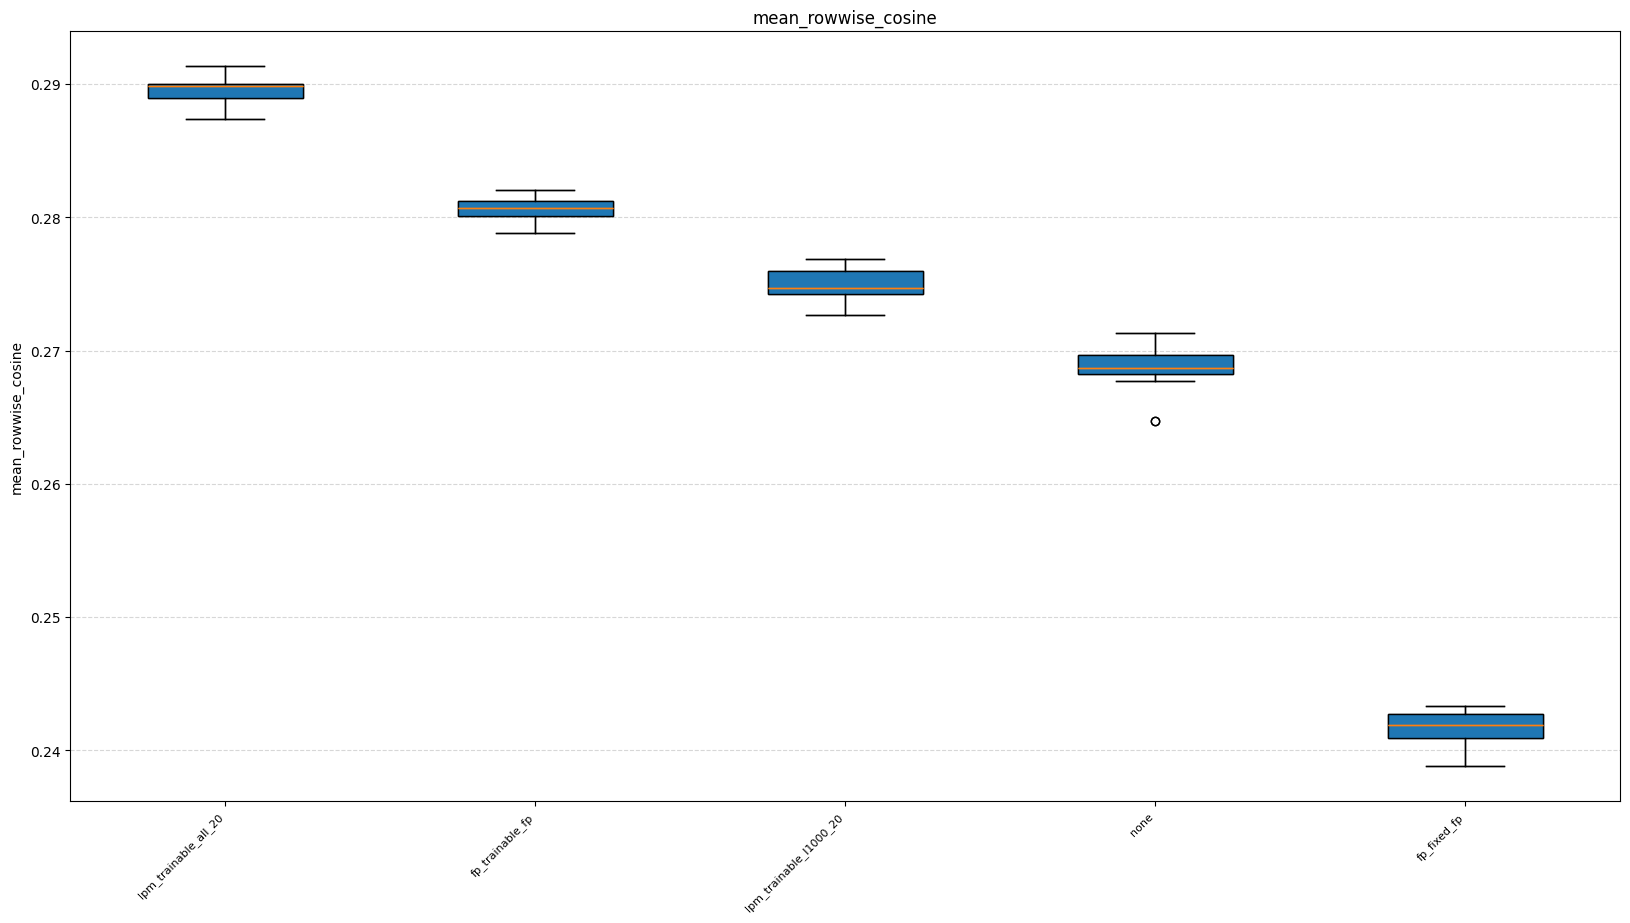

In [18]:
corr_metrics = ["mean_rowwise_pearson", "mean_rowwise_spearman", "mean_rowwise_cosine"]
for metric in corr_metrics:
    # higher correlation is better → sort descending
    methods_ordered = (
        df_method_corr.groupby("method_name")[metric]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    data_per_method = [
        df_method_corr.loc[df_method_corr["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    plt.figure(figsize=(20, 10))
    plt.boxplot(data_per_method, patch_artist=True, vert=True)
    plt.boxplot(data_per_method, patch_artist=True, vert=True)

    plt.xticks(
        range(1, len(methods_ordered) + 1),
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    plt.ylabel(metric)
    plt.title(metric)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.show()